<a href="https://colab.research.google.com/github/irsyadilham03/Irsyad-Ilham/blob/main/ASSIGNMENT1_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import sys

!{sys.executable} -m pip uninstall -y patsy statsmodels seaborn
!{sys.executable} -m pip install patsy statsmodels seaborn

print("Reinstallation complete. Please re-run the cell with the import statements.")

Found existing installation: patsy 1.0.2
Uninstalling patsy-1.0.2:
  Successfully uninstalled patsy-1.0.2
Found existing installation: statsmodels 0.14.6
Uninstalling statsmodels-0.14.6:
  Successfully uninstalled statsmodels-0.14.6
Found existing installation: seaborn 0.13.2
Uninstalling seaborn-0.13.2:
  Successfully uninstalled seaborn-0.13.2
  Using cached patsy-1.0.2-py2.py3-none-any.whl.metadata (3.6 kB)
  Using cached statsmodels-0.14.6-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl.metadata (9.5 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached patsy-1.0.2-py2.py3-none-any.whl (233 kB)
Using cached statsmodels-0.14.6-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl (10.3 MB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Reinstallation complete. Please re-run the cell with the import statements.


In [7]:
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures

# Models
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR

# Metrics
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [8]:
from google.colab import files
uploaded = files.upload()

Saving SolarPowerGenerationKaggle_MissingData.xlsx to SolarPowerGenerationKaggle_MissingData (5).xlsx


In [9]:
df = pd.read_excel('SolarPowerGenerationKaggle_MissingData (4).xlsx')
print(df.shape)
print(df.columns)
print(df.info())
print(df.isnull().sum())

(4213, 21)
Index(['temperature_2_m_above_gnd', 'relative_humidity_2_m_above_gnd',
       'mean_sea_level_pressure_MSL', 'total_precipitation_sfc',
       'snowfall_amount_sfc', 'total_cloud_cover_sfc',
       'high_cloud_cover_high_cld_lay', 'medium_cloud_cover_mid_cld_lay',
       'low_cloud_cover_low_cld_lay', 'shortwave_radiation_backwards_sfc',
       'wind_speed_10_m_above_gnd', 'wind_direction_10_m_above_gnd',
       'wind_speed_80_m_above_gnd', 'wind_direction_80_m_above_gnd',
       'wind_speed_900_mb', 'wind_direction_900_mb',
       'wind_gust_10_m_above_gnd', 'angle_of_incidence', 'zenith', 'azimuth',
       'generated_power_kw'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4213 entries, 0 to 4212
Data columns (total 21 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   temperature_2_m_above_gnd          4212 non-null   float64
 1   relative_humidity_2_m_ab

In [10]:
df = df.copy()

for col in df.columns:
    df[col].fillna(df[col].median(), inplace=True)

print(df.isnull().sum())

temperature_2_m_above_gnd            0
relative_humidity_2_m_above_gnd      0
mean_sea_level_pressure_MSL          0
total_precipitation_sfc              0
snowfall_amount_sfc                  0
total_cloud_cover_sfc                0
high_cloud_cover_high_cld_lay        0
medium_cloud_cover_mid_cld_lay       0
low_cloud_cover_low_cld_lay          0
shortwave_radiation_backwards_sfc    0
wind_speed_10_m_above_gnd            0
wind_direction_10_m_above_gnd        0
wind_speed_80_m_above_gnd            0
wind_direction_80_m_above_gnd        0
wind_speed_900_mb                    0
wind_direction_900_mb                0
wind_gust_10_m_above_gnd             0
angle_of_incidence                   0
zenith                               0
azimuth                              0
generated_power_kw                   0
dtype: int64


/tmp/ipykernel_47819/1277410780.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)


In [13]:
X = df.drop('generated_power_kw', axis=1)
y = df['generated_power_kw']

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [15]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [16]:
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

# Evaluation
r2_lr = r2_score(y_test, y_pred_lr)
mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))

print("Multiple Linear Regression:")
print("R2:", r2_lr)
print("MAE:", mae_lr)
print("RMSE:", rmse_lr)

Multiple Linear Regression:
R2: 0.7179597179796529
MAE: 391.8152879329382
RMSE: 507.5761799261741


In [17]:
poly = PolynomialFeatures(degree=2)

X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

poly_model = LinearRegression()
poly_model.fit(X_train_poly, y_train)

y_pred_poly = poly_model.predict(X_test_poly)

# Evaluation
r2_poly = r2_score(y_test, y_pred_poly)
mae_poly = mean_absolute_error(y_test, y_pred_poly)
rmse_poly = np.sqrt(mean_squared_error(y_test, y_pred_poly))

print("\nPolynomial Regression:")
print("R2:", r2_poly)
print("MAE:", mae_poly)
print("RMSE:", rmse_poly)


Polynomial Regression:
R2: -1.2236819597491926
MAE: 392.7289646701957
RMSE: 1425.2202985199483


In [18]:
svr = SVR(kernel='rbf')

svr.fit(X_train_scaled, y_train)

y_pred_svr = svr.predict(X_test_scaled)

# Evaluation
r2_svr = r2_score(y_test, y_pred_svr)
mae_svr = mean_absolute_error(y_test, y_pred_svr)
rmse_svr = np.sqrt(mean_squared_error(y_test, y_pred_svr))

print("\nSVR:")
print("R2:", r2_svr)
print("MAE:", mae_svr)
print("RMSE:", rmse_svr)


SVR:
R2: 0.1755486516346375
MAE: 765.6429267894415
RMSE: 867.8170511655546


In [19]:
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Polynomial Regression', 'SVR'],
    'R2 Score': [r2_lr, r2_poly, r2_svr],
    'MAE': [mae_lr, mae_poly, mae_svr],
    'RMSE': [rmse_lr, rmse_poly, rmse_svr]
})

print(results)

                   Model  R2 Score         MAE         RMSE
0      Linear Regression  0.717960  391.815288   507.576180
1  Polynomial Regression -1.223682  392.728965  1425.220299
2                    SVR  0.175549  765.642927   867.817051


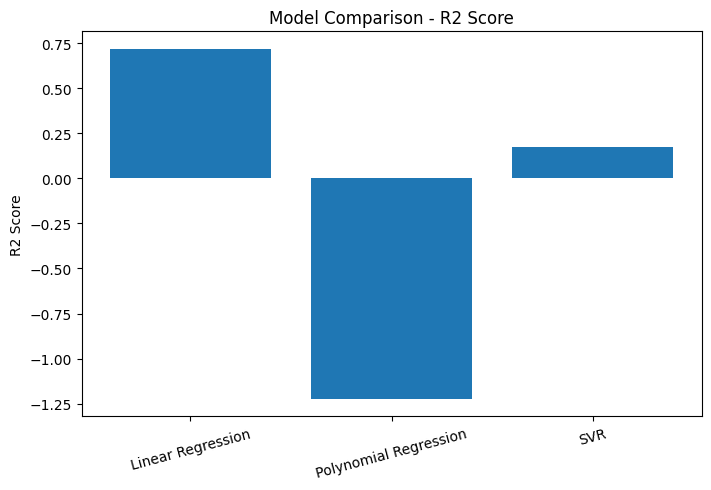

In [20]:
plt.figure(figsize=(8,5))
plt.bar(results['Model'], results['R2 Score'])
plt.title('Model Comparison - R2 Score')
plt.ylabel('R2 Score')
plt.xticks(rotation=15)
plt.show()

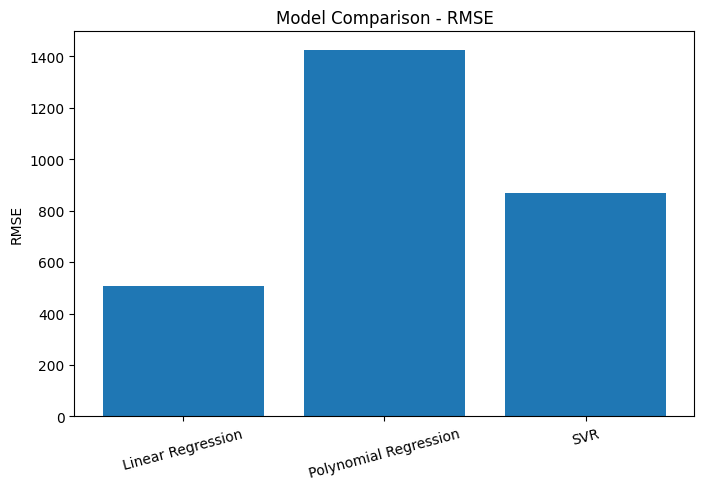

In [21]:
plt.figure(figsize=(8,5))
plt.bar(results['Model'], results['RMSE'])
plt.title('Model Comparison - RMSE')
plt.ylabel('RMSE')
plt.xticks(rotation=15)
plt.show()

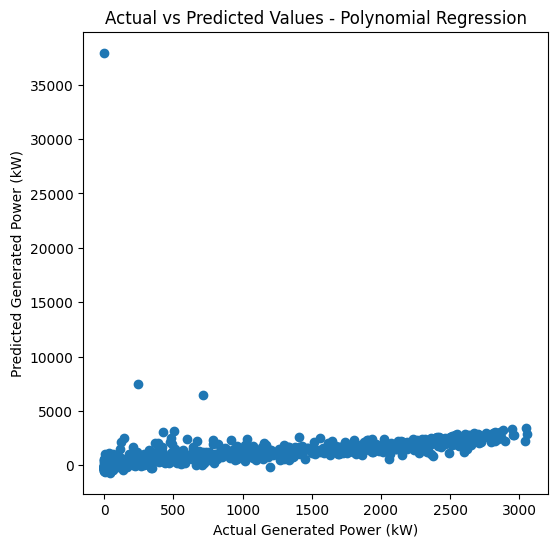

In [22]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_poly)
plt.xlabel('Actual Generated Power (kW)')
plt.ylabel('Predicted Generated Power (kW)')
plt.title('Actual vs Predicted Values - Polynomial Regression')
plt.show()

In [23]:
results.to_csv('solar_model_results.csv', index=False)

In [24]:
prediction_df = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred_poly
})

prediction_df.to_csv('solar_prediction.csv', index=False)

In [25]:
pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred_poly
}).to_csv('prediction.csv', index=False)

In [26]:
results.to_csv('solar_model_results.csv', index=False)

prediction_df.to_csv('solar_prediction.csv', index=False)

In [27]:
from google.colab import files
files.download('solar_model_results.csv')
files.download('solar_prediction.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>